In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import random
import scipy.linalg
import time
import pandas as pd
import seaborn as sb

In [2]:
def step_mat(K,dt):
    if K<0:
        return np.array([[np.cosh(dt*np.sqrt(-K)),np.sqrt(-K)*np.sinh(dt*np.sqrt(-K))],[1/np.sqrt(-K)*np.sinh(dt*np.sqrt(-K)),np.cosh(dt*np.sqrt(-K))]])
    if K==0:
        return np.array([[1,0],[dt,1]])
    if K>0:
        return np.array([[np.cos(dt*np.sqrt(K)),-np.sqrt(K)*np.sin(dt*np.sqrt(K))],[1/np.sqrt(K)*np.sin(dt*np.sqrt(K)),np.cos(dt*np.sqrt(K))]])

def arg(z):
    ans = np.arctan2(z[1],z[0])
    if ans<0:
        return ans+2*np.pi
    else:
        return ans
    
def new_arg(old_arg, K, dt):
    old_z = [np.cos(old_arg), np.sin(old_arg)]
    new_z = old_z @ step_mat(K, dt)
    return arg(new_z)

def new_sost(DP, old_sost, K, dt):
    oarg = np.pi / DP * (1 + 2 * old_sost)
    narg = new_arg(oarg, K, dt)
    return int(np.floor(narg * DP / 2 / np.pi))

### Сравнение устойчивости ЭФР, построенных по разному числу наблюдений

In [219]:
ZDG = np.load('zerosdiff_equiv_K_U(-1_1)_M1000_D1_R30000.npy')

In [221]:
ZDG = ZDG.reshape(ZDG.shape[0]*ZDG.shape[1])
ZDG = ZDG[ZDG != 0]
print(ZDG.shape)

(2988320,)


In [223]:
sizes = [100, 1000, 10000]
ZDG_ts = [[np.sort(ZDG_EU[size*m:size*(m+1)]) for m in range(250)] for size in sizes]

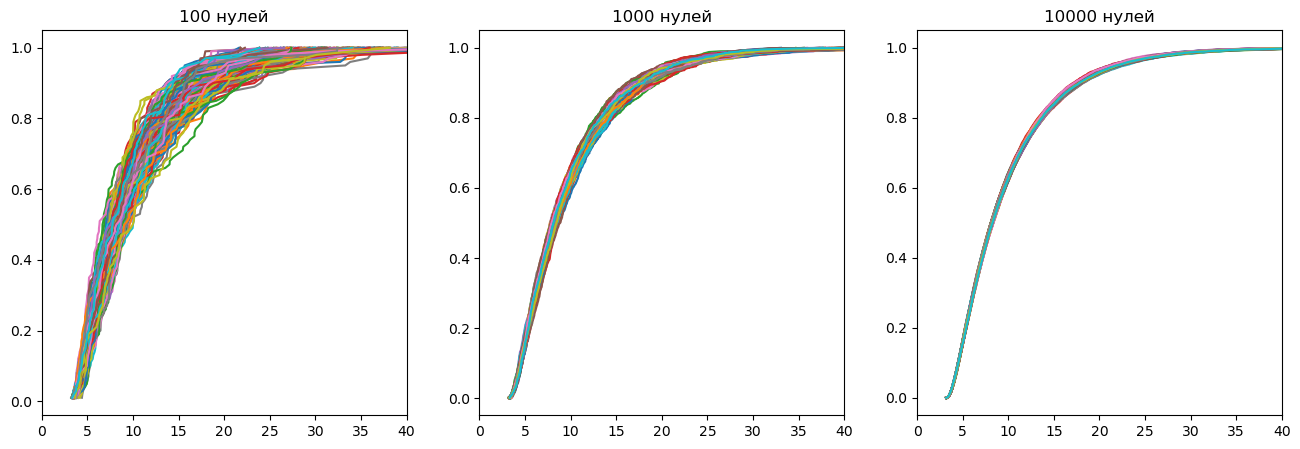

In [225]:
fig, ax = plt.subplots(1, 3, figsize=(16,5))
for i in range(3):
    ax[i].set(xlim=(0, 40))
    ax[i].set_title(f'{sizes[i]} нулей')
    for arr in ZDG_ts[i]:
        ax[i].plot(arr, np.linspace(1/len(arr), 1, len(arr)))
plt.show()

### Сравнение разных ЭФР

In [43]:
filenames = ['zerosdiff_equiv_K_U(-3_3)_M1000_D1_R600.npy',
             'zerosdiff_K_U(-3_3)_M1000_Dexp1_R1000.npy',
             'zerosdiff_K_N(0_1.7320508)_M1000_Dconst1_R1000.npy',
             'zerosdiff_K_N(0_1.7320508)_M1000_Dexp1_R1000.npy']
ZDGs = []
zn = 70000 # количество нулей
Kmaxs=[0.2, 0.5, 1, 3, 10, 50]

for filename in filenames:
    arr = np.load(filename)
    arr = arr[arr != 0]
    ZDGs.append(np.sort(arr[:zn]))

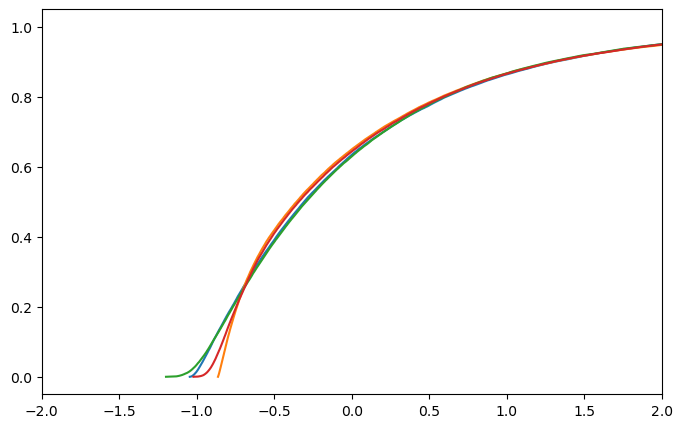

In [51]:
fig, ax = plt.subplots(1, figsize=(8,5))
ax.set(xlim=(-2,2))
for i in range(len(ZDGs)):
    #ax.plot(ZDGs[i], np.linspace(1/len(ZDGs[i]), 1, len(ZDGs[i])))
    ax.plot((ZDGs[i]-ZDGs[i].mean())/ZDGs[i].std(), np.linspace(1/len(ZDGs[i]), 1, len(ZDGs[i])))
#ax.legend()
plt.show()

In [55]:
[arr.mean() for arr in ZDGs], [arr.std() for arr in ZDGs]

([5.2122980277831905,
  5.551942300063548,
  5.6526779440430746,
  5.891593723468351],
 [3.244538192280621, 4.328177716183455, 3.691760294028736, 4.641796844573096])

### Сравнение разных условий (триптих)

In [96]:
zn = 70000

ZD_UC_3 = np.load('zerosdiff_equiv_K_U(-3_3)_M1000_D1_R600.npy')
ZD_NC_3 = np.load('zerosdiff_K_N(0_1.7320508)_M1000_Dconst1_R1000.npy')
ZD_UE_3 = np.load('zerosdiff_K_U(-3_3)_M1000_Dexp1_R1000.npy')
ZD_NE_3 = np.load('zerosdiff_K_N(0_1.7320508)_M1000_Dexp1_R1000.npy')

ZD_UC_10 = np.load('zerosdiff_equiv_K_U(-10_10)_M1000_D1_R300.npy')
ZD_NC_10 = np.load('zerosdiff_K_N(0_5.7735027)_M1000_Dconst1_R1000.npy')
ZD_UE_10 = np.load('zerosdiff_K_U(-10_10)_M1000_Dexp1_R1000.npy')
ZD_NE_10 = np.load('zerosdiff_K_N(0_5.7735027)_M1000_Dexp1_R1000.npy')

ZD_UC_50 = np.load('zerosdiff_equiv_K_U(-50_50)_M1000_D1_R200.npy')
ZD_NC_50 = np.load('zerosdiff_K_N(0_28.86751)_M1000_Dconst1_R1000.npy')
ZD_UE_50 = np.load('zerosdiff_K_U(-50_50)_M1000_Dexp1_R1000.npy')
ZD_NE_50 = np.load('zerosdiff_K_N(0_28.86751)_M1000_Dexp1_R1000.npy')

ZDs3 = [ZD_UC_3, ZD_NC_3, ZD_UE_3, ZD_NE_3]
ZDs10 = [ZD_UC_10, ZD_NC_10, ZD_UE_10, ZD_NE_10]
ZDs50 = [ZD_UC_50, ZD_NC_50, ZD_UE_50, ZD_NE_50]

for i in range(len(ZDs3)):
    arr = ZDs3[i]
    arr = arr.reshape(arr.shape[0] * arr.shape[1])
    arr = arr[arr != 0]
    ZDs3[i] = np.sort(arr)

for i in range(len(ZDs10)):
    arr = ZDs10[i]
    arr = arr.reshape(arr.shape[0] * arr.shape[1])
    arr = arr[arr != 0]
    ZDs10[i] = np.sort(arr)

for i in range(len(ZDs50)):
    arr = ZDs50[i]
    arr = arr.reshape(arr.shape[0] * arr.shape[1])
    arr = arr[arr != 0]
    ZDs50[i] = np.sort(arr)

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_7784\1101309964.py:3: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_title('$K_{\max}=3$')
C:\Users\HP\AppData\Local\Temp\ipykernel_7784\1101309964.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_title('$K_{\max}=10$')
C:\Users\HP\AppData\Local\Temp\ipykernel_7784\1101309964.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_title('$K_{\max}=50$')


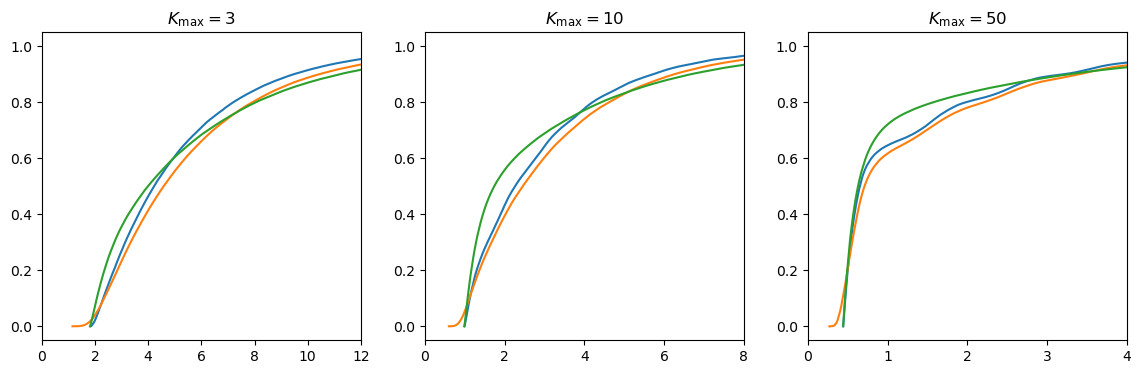

In [98]:
fig, ax = plt.subplots(1, 3, figsize=(14,4))

ax[0].set_title('$K_{\max}=3$')
ax[0].set(xlim=(0,12))
for arr in ZDs3[:3]:
    ax[0].plot(arr, np.linspace(1/len(arr), 1, len(arr)))

ax[1].set_title('$K_{\max}=10$')
ax[1].set(xlim=(0,8))
for arr in ZDs10[:3]:
    ax[1].plot(arr, np.linspace(1/len(arr), 1, len(arr)))

ax[2].set_title('$K_{\max}=50$')
ax[2].set(xlim=(0,4))
for arr in ZDs50[:3]:
    ax[2].plot(arr, np.linspace(1/len(arr), 1, len(arr)))

plt.show()

### Сравнение разных условий (4 пары)

In [7]:
filenames = ['zerosdiff_equiv_K_U(-3_3)_M1000_D1_R600.npy',
             'zerosdiff_K_N(0_1.7320508)_M1000_Dconst1_R1000.npy',
             'zerosdiff_K_U(-3_3)_M1000_Dexp1_R1000.npy',
             'zerosdiff_K_N(0_1.7320508)_M1000_Dexp1_R1000.npy']
ZDs = []

for fn in filenames:
    arr = np.load(fn)
    arr = arr.reshape(arr.shape[0] * arr.shape[1])
    arr = arr[arr != 0]
    ZDs.append(np.sort(arr))

ZD_UC, ZD_NC, ZD_UE, ZD_NE = ZDs

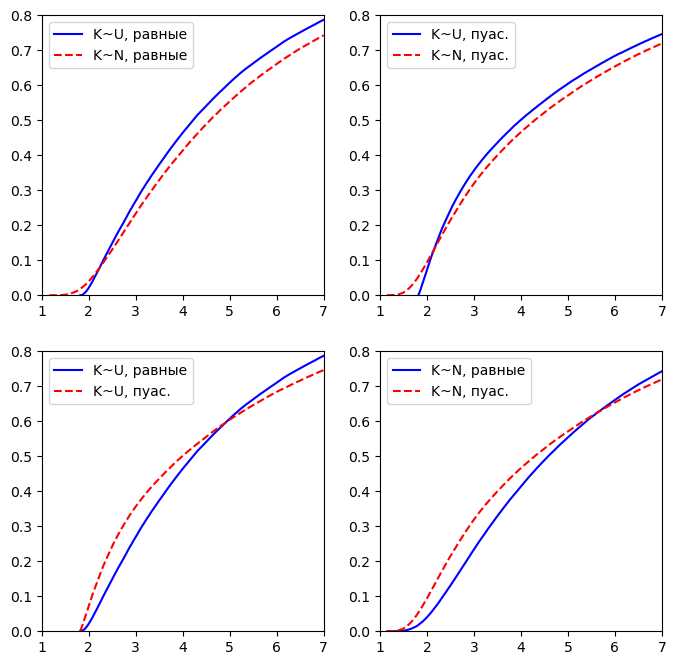

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(8,8))

ax[0,0].set(xlim=(1,7), ylim=(0,0.8))
ax[0,0].plot(ZD_UC, np.linspace(1/len(ZD_UC), 1, len(ZD_UC)), c='blue', label = 'K~U, равные')
ax[0,0].plot(ZD_NC, np.linspace(1/len(ZD_NC), 1, len(ZD_NC)), c='red', ls='--', label = 'K~N, равные')
ax[0,0].legend()

ax[0,1].set(xlim=(1,7), ylim=(0,0.8))
ax[0,1].plot(ZD_UE, np.linspace(1/len(ZD_UE), 1, len(ZD_UE)), c='blue', label = 'K~U, пуас.')
ax[0,1].plot(ZD_NE, np.linspace(1/len(ZD_NE), 1, len(ZD_NE)), c='red', ls='--', label = 'K~N, пуас.')
ax[0,1].legend()

ax[1,0].set(xlim=(1,7), ylim=(0,0.8))
ax[1,0].plot(ZD_UC, np.linspace(1/len(ZD_UC), 1, len(ZD_UC)), c='blue', label = 'K~U, равные')
ax[1,0].plot(ZD_UE, np.linspace(1/len(ZD_UE), 1, len(ZD_UE)), c='red', ls='--', label = 'K~U, пуас.')
ax[1,0].legend()

ax[1,1].set(xlim=(1,7), ylim=(0,0.8))
ax[1,1].plot(ZD_NC, np.linspace(1/len(ZD_NC), 1, len(ZD_NC)), c='blue', label = 'K~N, равные')
ax[1,1].plot(ZD_NE, np.linspace(1/len(ZD_NE), 1, len(ZD_NE)), c='red', ls='--', label = 'K~N, пуас.')
ax[1,1].legend()

#ax[1,0].set(xlim=(0,5),ylim=(0,0.5))
#ax[1,0].plot(ZDG_EU_2, np.linspace(1/ZDG_EU_2.shape[0],1,ZDG_EU_2.shape[0]), label = 'eq, $U(-3,3)$')
#ax[1,0].plot(ZDG_PU_2, np.linspace(1/ZDG_PU_2.shape[0],1,ZDG_PU_2.shape[0]), label = 'pois, $U(-3,3)$')
#ax[1,0].legend()

#ax[1,1].set(xlim=(0,5),ylim=(0,0.5))
#ax[1,1].plot(ZDG_EN_2, np.linspace(1/ZDG_EN_2.shape[0],1,ZDG_EN_2.shape[0]), label = 'eq, $N(0,1.732)$')
#ax[1,1].plot(ZDG_PN_2, np.linspace(1/ZDG_PN_2.shape[0],1,ZDG_PN_2.shape[0]), label = 'pois, $N(0,1.732)$')
#ax[1,1].legend()

plt.show()

### Минимальное расстояние

In [103]:
filenames = ['zerosdiff_equiv_K_U(-400_400)_M1000_D1_R50.npy',
             'zerosdiff_equiv_K_U(-100_100)_M1000_D1_R100.npy',
             'zerosdiff_equiv_K_U(-90_90)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-80_80)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-70_70)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-60_60)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-50_50)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-40_40)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-35_35)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-30_30)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-25_25)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-20_20)_M1000_D1_R250.npy',
             'zerosdiff_equiv_K_U(-15_15)_M1000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-10_10)_M1000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-9_9)_M1000_D1_R350.npy',
             'zerosdiff_equiv_K_U(-8_8)_M1000_D1_R350.npy',
             'zerosdiff_equiv_K_U(-7_7)_M1000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-6_6)_M1000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-5_5)_M1000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-4_4)_M1000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-3_3)_M1000_D1_R600.npy',
             'zerosdiff_equiv_K_U(-2_2)_M1000_D1_R800.npy',
             'zerosdiff_equiv_K_U(-1_1)_M1000_D1_R30000.npy',
             'zerosdiff_equiv_K_U(-0.5_0.5)_M5000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-0.4_0.4)_M5000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-0.3_0.3)_M5000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-0.2_0.2)_M5000_D1_R600.npy', 
             'zerosdiff_equiv_K_U(-0.1_0.1)_M5000_D1_R1000.npy', 
             'zerosdiff_equiv_K_U(-0.05_0.05)_M5000_D1_R1500.npy',
             'zerosdiff_equiv_K_U(-0.02_0.02)_M5000_D1_R2500.npy',
             'zerosdiff_equiv_K_U(-0.01_0.01)_M5000_D1_R3000.npy',
             'zerosdiff_equiv_K_U(-0.005_0.005)_M5000_D1_R5000.npy',
             'zerosdiff_equiv_K_U(-0.002_0.002)_M10000_D1_R5000.npy',
             'zerosdiff_equiv_K_U(-0.001_0.001)_M10000_D1_R8000.npy']
ZDGs = []
zn = 10000 # количество нулей

for filename in filenames:
    arr = np.load(filename)
    arr = arr[arr != 0]
    ZDGs.append(np.sort(arr))

In [105]:
Kmaxs = np.array([400, 100, 90, 80, 70, 60, 50, 40, 35, 30, 25, 20, 15, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001])
nmins = np.array([arr.min() for arr in ZDGs])

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_3764\2978069202.py:3: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(np.log(Kmaxs), np.log(np.pi) - 0.5 * np.log(Kmaxs), ls='--', c='red', label='$\pi K_{\max}^{-1/2}$')
C:\Users\HP\AppData\Local\Temp\ipykernel_3764\2978069202.py:4: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(np.log(Kmaxs), 0.764 - 2/3 * np.log(Kmaxs), ls='-.', c='blue', label='$0.76 K_{\max}^{-2/3}$')


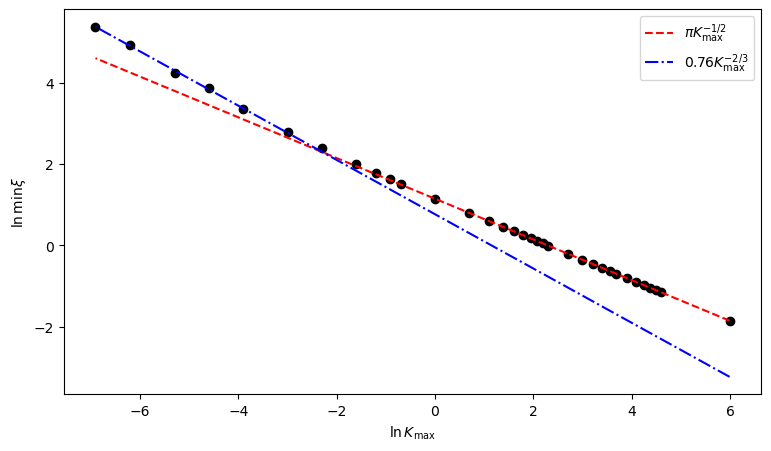

In [107]:
fig, ax = plt.subplots(1, figsize=(9,5))
ax.scatter(np.log(Kmaxs), np.log(nmins), c='black')
ax.plot(np.log(Kmaxs), np.log(np.pi) - 0.5 * np.log(Kmaxs), ls='--', c='red', label='$\pi K_{\max}^{-1/2}$')
ax.plot(np.log(Kmaxs), 0.764 - 2/3 * np.log(Kmaxs), ls='-.', c='blue', label='$0.76 K_{\max}^{-2/3}$')
ax.set_xlabel(r'$\ln{K_{\max}}$')
ax.set_ylabel(r'$\ln{\min{\xi}}$')
ax.legend()
plt.show()

In [244]:
x = np.log(Kmaxs)[:6]

In [246]:
y = np.log(nmins)[:6]

In [252]:
1/6 * np.sum(y + 2/3*x)

0.7638062767939925

In [95]:
filenames = ['zerosdiff_equiv_K_U(-400_400)_M1000_D1_R50.npy',
             'zerosdiff_equiv_K_U(-100_100)_M1000_D1_R100.npy',
             'zerosdiff_equiv_K_U(-90_90)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-80_80)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-70_70)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-60_60)_M1000_D1_R150.npy',
             'zerosdiff_equiv_K_U(-50_50)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-40_40)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-35_35)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-30_30)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-25_25)_M1000_D1_R200.npy',
             'zerosdiff_equiv_K_U(-20_20)_M1000_D1_R250.npy',
             'zerosdiff_equiv_K_U(-15_15)_M1000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-10_10)_M1000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-9_9)_M1000_D1_R350.npy',
             'zerosdiff_equiv_K_U(-8_8)_M1000_D1_R350.npy',
             'zerosdiff_equiv_K_U(-7_7)_M1000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-6_6)_M1000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-5_5)_M1000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-4_4)_M1000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-3_3)_M1000_D1_R600.npy',
             'zerosdiff_equiv_K_U(-2_2)_M1000_D1_R800.npy',
             'zerosdiff_equiv_K_U(-1_1)_M1000_D1_R30000.npy',
             'zerosdiff_equiv_K_U(-0.5_0.5)_M5000_D1_R300.npy',
             'zerosdiff_equiv_K_U(-0.4_0.4)_M5000_D1_R400.npy',
             'zerosdiff_equiv_K_U(-0.3_0.3)_M5000_D1_R500.npy',
             'zerosdiff_equiv_K_U(-0.2_0.2)_M5000_D1_R600.npy', 
             'zerosdiff_equiv_K_U(-0.1_0.1)_M5000_D1_R1000.npy', 
             'zerosdiff_equiv_K_U(-0.05_0.05)_M5000_D1_R1500.npy',
             'zerosdiff_equiv_K_U(-0.02_0.02)_M5000_D1_R2500.npy',
             'zerosdiff_equiv_K_U(-0.01_0.01)_M5000_D1_R3000.npy',
             'zerosdiff_equiv_K_U(-0.005_0.005)_M5000_D1_R5000.npy',
             'zerosdiff_equiv_K_U(-0.002_0.002)_M10000_D1_R5000.npy',
             'zerosdiff_equiv_K_U(-0.001_0.001)_M10000_D1_R8000.npy']
ZDGs = []
zn = 10000 # количество нулей

for filename in filenames:
    arr = np.load(filename)
    arr = arr[arr != 0]
    ZDGs.append(np.sort(arr))

In [97]:
Kmaxs = np.array([400, 100, 90, 80, 70, 60, 50, 40, 35, 30, 25, 20, 15, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001])
navgs = np.array([arr.mean() for arr in ZDGs])

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_3764\2865552963.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(np.log(Kmaxs), 2.193-2/3*np.log(Kmaxs), ls='-.', c='blue', label='$2.19 K_{\max}^{-2/3}$')
C:\Users\HP\AppData\Local\Temp\ipykernel_3764\2865552963.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(np.log(Kmaxs), 2.23-1/2*np.log(Kmaxs), ls='--', c='red', label='$2.23 K_{\max}^{-1/2}$')


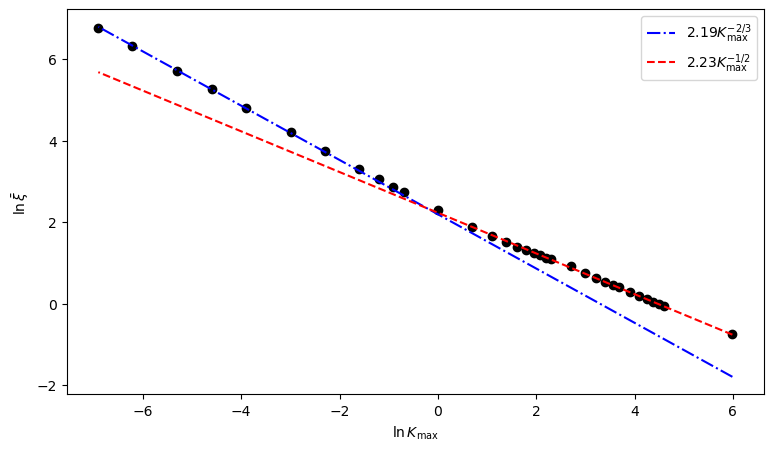

In [101]:
Kmaxs = Kmaxs
navgs = navgs

fig, ax = plt.subplots(1, figsize=(9,5))
#ax.set(xlim=(0, 10), ylim=(-2, 3))
ax.scatter(np.log(Kmaxs), np.log(navgs), c='black')
ax.plot(np.log(Kmaxs), 2.193-2/3*np.log(Kmaxs), ls='-.', c='blue', label='$2.19 K_{\max}^{-2/3}$')
ax.plot(np.log(Kmaxs), 2.23-1/2*np.log(Kmaxs), ls='--', c='red', label='$2.23 K_{\max}^{-1/2}$')
ax.set_xlabel(r'$\ln{K_{\max}}$')
ax.set_ylabel(r'$\ln\bar{\xi}$')
ax.legend()
plt.show()

In [337]:
x = np.log(Kmaxs[-7:])
y = np.log(navgs[-7:])

In [341]:
1/7 * np.sum(y + 2/3*x)

2.1937749838065836

In [345]:
np.e ** 2.2

9.025013499434122